# Composition of `drug_viability_table.parquet`

EDA of the harmonized cell_line × drug × SMILES × viability table (built from the prophet
singleton drug-response screens GDSC / CTRP / PRISM; all cell lines are CCLE stripped names).

Sections: (1) structure, (2) per-dataset composition, (3) viability distributions,
(4) coverage completeness, (5) drug-name/SMILES consistency & data quality,
(6) cross-dataset overlap.

In [1]:
import itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PARQUET = "/lustre/groups/ml01/workspace/xiaotong.fu/pancellflow/sub/analysis/drug_viability_table.parquet"
df = pd.read_parquet(PARQUET)
D = sorted(df["dataset"].unique())
print("loaded", df.shape, "| datasets:", D)

loaded (2863598, 5) | datasets: ['CTRP', 'GDSC', 'PRISM']


## 1. Structure

In [2]:
print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes)
print("\nmemory: %.1f MB" % (df.memory_usage(deep=True).sum() / 1e6))
print("\nunique per column:", {c: int(df[c].nunique()) for c in df.columns})
print("NaN per column:", df.isna().sum().to_dict())
display(df.head())

shape: (2863598, 5)

dtypes:
 cell_line     object
drug          object
smiles        object
viability    float64
dataset       object
dtype: object



memory: 882.1 MB



unique per column: {'cell_line': 1319, 'drug': 4652, 'smiles': 4741, 'viability': 2856837, 'dataset': 3}


NaN per column: {'cell_line': 0, 'drug': 0, 'smiles': 0, 'viability': 0, 'dataset': 0}


,cell_line,drug,smiles,viability,dataset
0,22RV1,123138,123138,0.506425,GDSC
1,22RV1,123829,123829,0.408058,GDSC
2,22RV1,150412,150412,0.455465,GDSC
3,22RV1,5-Fluorouracil,O=c1[nH]cc(F)c(=O)[nH]1,0.490291,GDSC
4,22RV1,5-azacytidine,C1=NC(=NC(=O)N1C2C(C(C(O2)CO)O)O)N,0.528872,GDSC


## 2. Per-dataset composition

Rows, unique cell lines, unique drugs (by name vs SMILES), measured pairs, and grid density
(measured / full cell_line × drug grid).

,rows,cell_lines,drugs_by_name,drugs_by_smiles,pairs,grid_density
dataset,,,,,,
CTRP,387258,887,545,545,387258,0.801
GDSC,235415,967,286,285,234703,0.852
PRISM,2240925,567,4046,4043,2239268,0.977


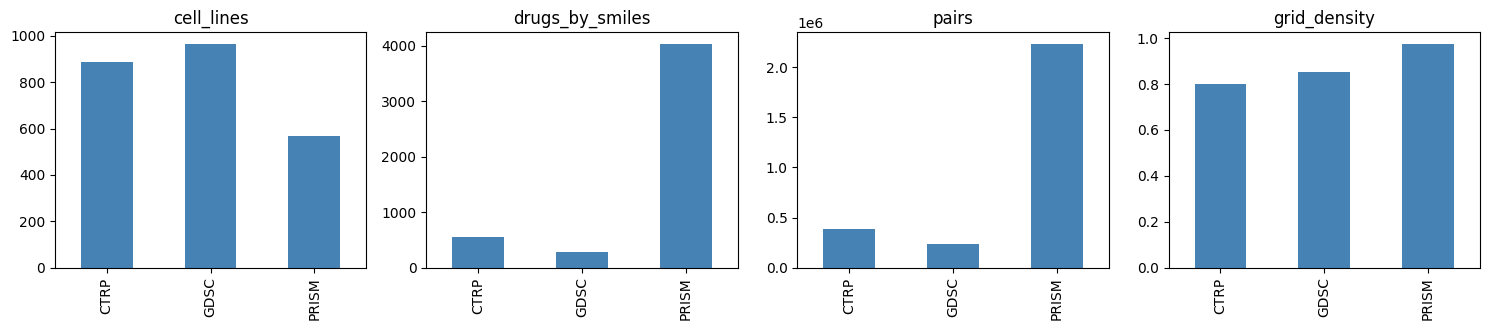

In [3]:
rows = []
for d in D:
    g = df[df.dataset == d]
    pairs = g.drop_duplicates(["cell_line", "smiles"]).shape[0]
    rows.append(dict(dataset=d, rows=len(g), cell_lines=g.cell_line.nunique(),
                     drugs_by_name=g.drug.nunique(), drugs_by_smiles=g.smiles.nunique(),
                     pairs=pairs, grid_density=pairs / (g.cell_line.nunique() * g.smiles.nunique())))
comp = pd.DataFrame(rows).set_index("dataset")
display(comp.round(3))

fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for a, col in zip(ax, ["cell_lines", "drugs_by_smiles", "pairs", "grid_density"]):
    comp[col].plot.bar(ax=a, title=col, color="steelblue"); a.set_xlabel("")
plt.tight_layout(); plt.show()

## 3. Viability distributions

The screens use different scales/assays, so the raw viability distributions differ — this is
why rank (Spearman), not absolute value, is comparable across datasets.

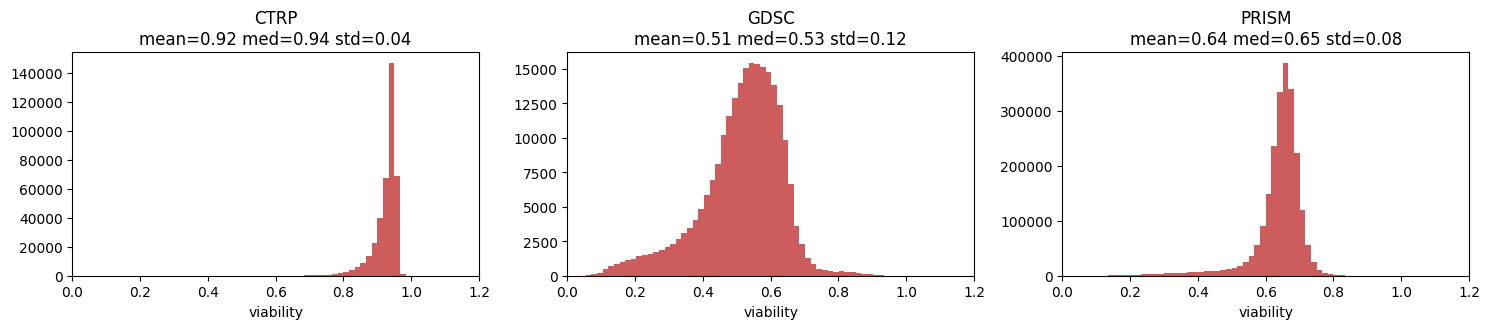

,mean,median,std,frac_kill_lt0_5,frac_inactive_gt0_8
dataset,,,,,
CTRP,0.925,0.937,0.038,0.000,0.985
GDSC,0.514,0.532,0.121,0.382,0.007
PRISM,0.638,0.652,0.075,0.050,0.001


In [4]:
fig, ax = plt.subplots(1, len(D), figsize=(5 * len(D), 3.4))
for a, d in zip(ax, D):
    v = df.loc[df.dataset == d, "viability"].dropna()
    a.hist(v, bins=60, color="indianred")
    a.set_title(f"{d}\nmean={v.mean():.2f} med={v.median():.2f} std={v.std():.2f}")
    a.set_xlabel("viability"); a.set_xlim(0, 1.2)
plt.tight_layout(); plt.show()

stat = df.groupby("dataset")["viability"].agg(
    mean="mean", median="median", std="std",
    frac_kill_lt0_5=lambda v: (v < 0.5).mean(),
    frac_inactive_gt0_8=lambda v: (v > 0.8).mean())
display(stat.round(3))

## 4. Coverage completeness

How many drugs are measured per cell line, and how many cell lines per drug — i.e. is each
dataset a dense grid or a sparse scatter?

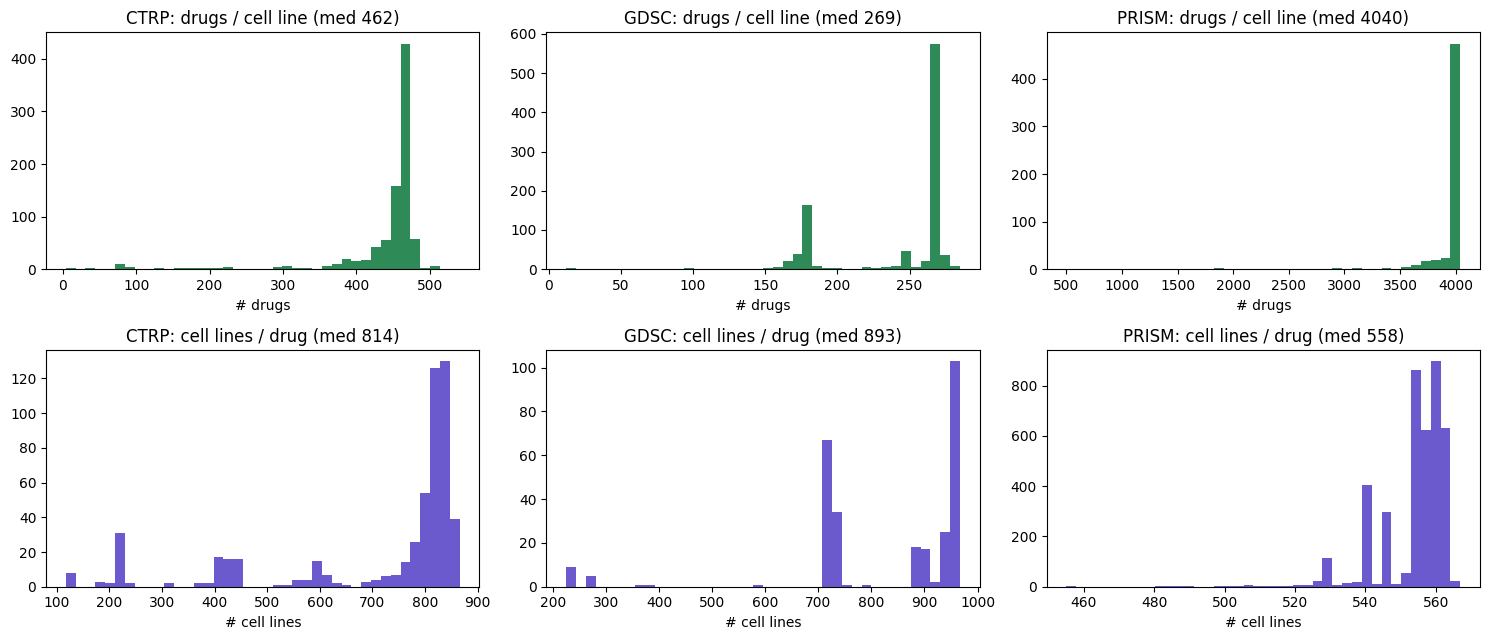

In [5]:
fig, ax = plt.subplots(2, len(D), figsize=(5 * len(D), 6.5))
for i, d in enumerate(D):
    g = df[df.dataset == d]
    dpc = g.groupby("cell_line").smiles.nunique()
    cpd = g.groupby("smiles").cell_line.nunique()
    ax[0, i].hist(dpc, bins=40, color="seagreen")
    ax[0, i].set_title(f"{d}: drugs / cell line (med {int(dpc.median())})"); ax[0, i].set_xlabel("# drugs")
    ax[1, i].hist(cpd, bins=40, color="slateblue")
    ax[1, i].set_title(f"{d}: cell lines / drug (med {int(cpd.median())})"); ax[1, i].set_xlabel("# cell lines")
plt.tight_layout(); plt.show()

## 5. Drug-name ↔ SMILES consistency & data quality

Do names map 1:1 to SMILES? Any malformed/duplicated SMILES, NaNs, out-of-range viability,
or duplicate rows?

In [6]:
n2s = df.groupby("drug").smiles.nunique()
s2n = df.groupby("smiles").drug.nunique()
print(f"drug names mapping to >1 SMILES: {(n2s > 1).sum()} / {len(n2s)}")
print(f"SMILES mapping to >1 drug name: {(s2n > 1).sum()} / {len(s2n)}")
multi = df.smiles.astype(str).str.contains(",", na=False)
print(f"rows with ',' in SMILES (repeated/combo quirk): {multi.sum()} ({multi.mean():.2%})")
print(f"viability range: [{df.viability.min():.3f}, {df.viability.max():.3f}] | NaN: {df.viability.isna().sum()} "
      f"| <0 or >1: {((df.viability < 0) | (df.viability > 1)).sum()}")
print(f"duplicate (dataset, cell_line, smiles) rows: {df.duplicated(['dataset','cell_line','smiles']).sum()}")
print("\nexamples of names with multiple SMILES:")
display(n2s[n2s > 1].sort_values(ascending=False).head())

drug names mapping to >1 SMILES: 156 / 4652
SMILES mapping to >1 drug name: 72 / 4741


rows with ',' in SMILES (repeated/combo quirk): 1094099 (38.21%)
viability range: [0.000, 1.000] | NaN: 0 | <0 or >1: 0


duplicate (dataset, cell_line, smiles) rows: 2369

examples of names with multiple SMILES:


drug
AZD7762       3
UNC0638       3
OSI-027       3
NVP-ADW742    3
SN-38         3
Name: smiles, dtype: int64

## 6. Cross-dataset overlap (cell lines & drugs)

Cell lines are the shared axis; drugs are largely complementary (each screen uses a different
library), so combining mainly adds cell-line breadth + new compounds.

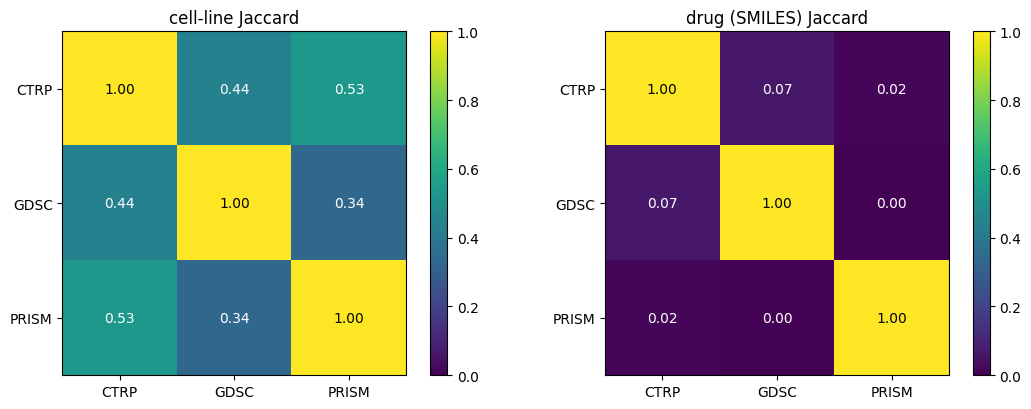

cell lines : 3-way ∩ = 358 | union = 1319
drugs(SMI) : 3-way ∩ = 11 | union = 4741


In [7]:
cl = {d: set(df[df.dataset == d].cell_line) for d in D}
dr = {d: set(df[df.dataset == d].smiles) for d in D}

def jac(sets):
    M = pd.DataFrame(index=D, columns=D, dtype=float)
    for a in D:
        for b in D:
            M.loc[a, b] = len(sets[a] & sets[b]) / len(sets[a] | sets[b])
    return M

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, (M, t) in zip(ax, [(jac(cl), "cell-line Jaccard"), (jac(dr), "drug (SMILES) Jaccard")]):
    im = a.imshow(M.values.astype(float), vmin=0, vmax=1, cmap="viridis")
    a.set_xticks(range(len(D))); a.set_xticklabels(D); a.set_yticks(range(len(D))); a.set_yticklabels(D)
    for i in range(len(D)):
        for j in range(len(D)):
            a.text(j, i, f"{M.iloc[i, j]:.2f}", ha="center", va="center",
                   color="w" if M.iloc[i, j] < 0.6 else "k")
    a.set_title(t); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

print("cell lines : 3-way ∩ =", len(set.intersection(*cl.values())), "| union =", len(set.union(*cl.values())))
print("drugs(SMI) : 3-way ∩ =", len(set.intersection(*dr.values())), "| union =", len(set.union(*dr.values())))

## 7. Is a cell line's viability *indicative*? — dynamic range

Some cell lines showed high cross-dataset agreement and some near-zero. A cell line whose drugs
all give similar viability (flat profile) can't discriminate drugs — its ranking is noise — while
a wide spread means the viability is informative. We measure per-cell-line **dynamic range** (std
of viability across its drugs) and check it predicts the cross-dataset agreement.

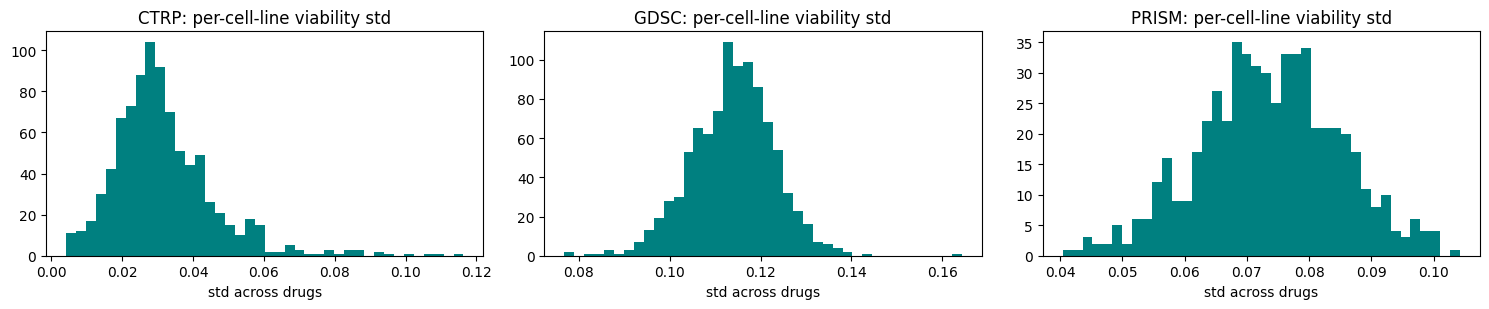

median per-cell-line dynamic range:


,std,iqr,rng
dataset,,,
CTRP,0.029,0.032,0.190
GDSC,0.114,0.132,0.714
PRISM,0.073,0.055,0.617


In [8]:
spread = (df.groupby(["dataset", "cell_line"])["viability"]
          .agg(n_drugs="count", std="std",
               iqr=lambda v: v.quantile(.75) - v.quantile(.25),
               rng=lambda v: v.max() - v.min()).reset_index())
spread = spread[spread.n_drugs >= 10]
fig, ax = plt.subplots(1, len(D), figsize=(5 * len(D), 3.2))
for a, d in zip(ax, D):
    a.hist(spread.loc[spread.dataset == d, "std"], bins=40, color="teal")
    a.set_title(f"{d}: per-cell-line viability std"); a.set_xlabel("std across drugs")
plt.tight_layout(); plt.show()
print("median per-cell-line dynamic range:")
display(spread.groupby("dataset")[["std", "iqr", "rng"]].median().round(3))

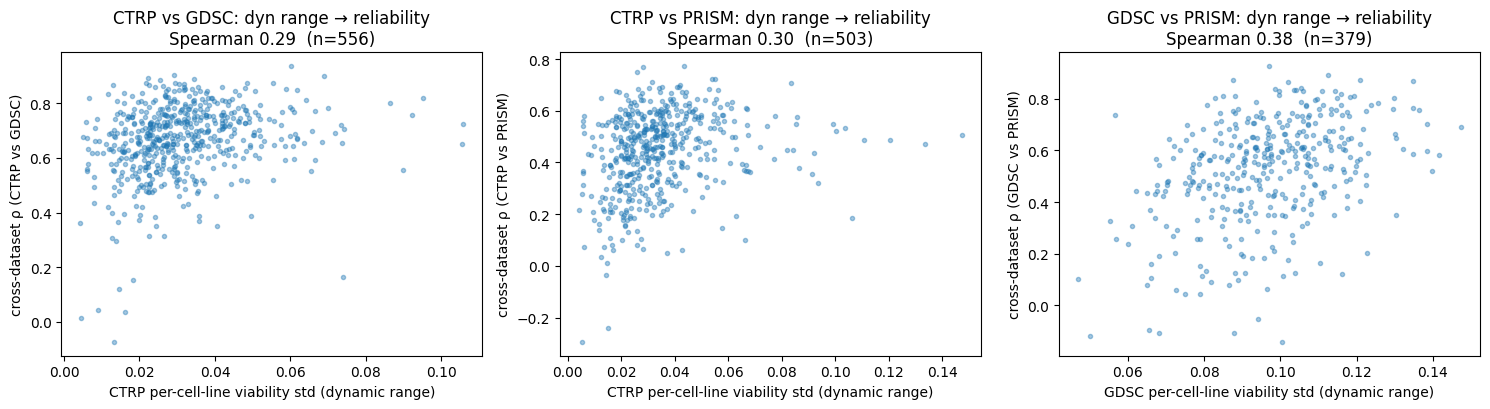

corr(dynamic range, cross-dataset agreement) per pair:
  CTRP vs GDSC   corr=+0.29  (n=556)
  CTRP vs PRISM  corr=+0.30  (n=503)
  GDSC vs PRISM  corr=+0.38  (n=379)
=> per-cell-line viability std is a usable *indicativeness* score (available for ALL cell lines)


In [9]:
# verify across ALL dataset pairs: does dynamic range predict cross-dataset agreement?
from scipy.stats import spearmanr
agg = {d: df[df.dataset == d].groupby(["cell_line", "smiles"], as_index=False)["viability"].mean()
       for d in D}
pairs = list(itertools.combinations(D, 2))
fig, ax = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.2))
summary = []
for a, (A, B) in zip(np.atleast_1d(ax), pairs):
    j = agg[A].merge(agg[B], on=["cell_line", "smiles"], suffixes=("_a", "_b"))
    recs = []
    for cl, g in j.groupby("cell_line"):
        if g.smiles.nunique() >= 10 and g.viability_a.std() > 0 and g.viability_b.std() > 0:
            recs.append((spearmanr(g.viability_a, g.viability_b).statistic, g.viability_a.std()))
    rr = pd.DataFrame(recs, columns=["rho", "dyn_range"]).dropna()
    r = spearmanr(rr.dyn_range, rr.rho).statistic
    summary.append((f"{A} vs {B}", len(rr), round(float(r), 2)))
    a.scatter(rr.dyn_range, rr.rho, s=9, alpha=0.4)
    a.set_xlabel(f"{A} per-cell-line viability std (dynamic range)")
    a.set_ylabel(f"cross-dataset ρ ({A} vs {B})")
    a.set_title(f"{A} vs {B}: dyn range → reliability\nSpearman {r:.2f}  (n={len(rr)})")
plt.tight_layout(); plt.show()
print("corr(dynamic range, cross-dataset agreement) per pair:")
for p, n, r in summary:
    print(f"  {p:<14} corr={r:+.2f}  (n={n})")
print("=> per-cell-line viability std is a usable *indicativeness* score (available for ALL cell lines)")

## 8. The drug's signal *relative to other drugs* — within-cell-line normalization

Raw viability mixes the cell line's baseline sensitivity and the assay scale with the
drug-specific effect. The model-relevant signal is the drug's deviation from the cell line's own
drug distribution: a within-cell-line **z-score** — how far (and which direction) this drug pushes
viability vs the cell line's typical response.

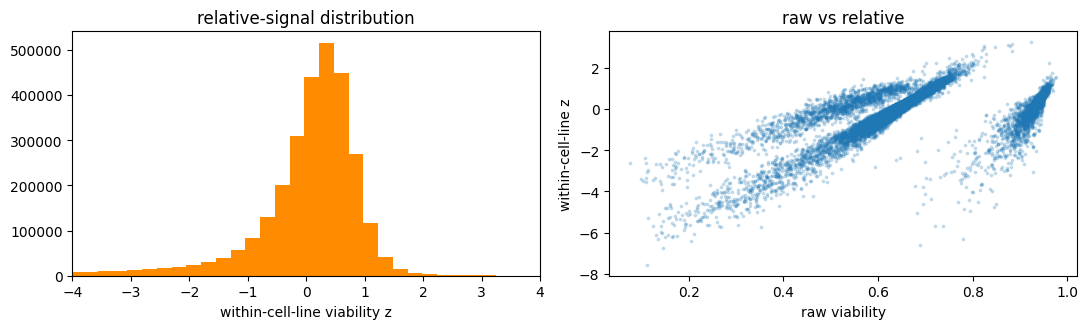

z << 0 : drug kills more than this cell line's typical drug (strong, specific hit)
z ~ 0  : behaves like the cell line's average drug (uninformative)
z >> 0 : unusually tolerated


In [10]:
g = df.groupby(["dataset", "cell_line"])["viability"]
df["v_z"] = (df["viability"] - g.transform("mean")) / g.transform("std")
df["v_pct"] = g.transform(lambda v: v.rank(pct=True))
samp = df.dropna(subset=["v_z"]).sample(min(20000, len(df)), random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(df["v_z"].dropna(), bins=80, color="darkorange"); ax[0].set_xlim(-4, 4)
ax[0].set_xlabel("within-cell-line viability z"); ax[0].set_title("relative-signal distribution")
ax[1].scatter(samp["viability"], samp["v_z"], s=3, alpha=0.2)
ax[1].set_xlabel("raw viability"); ax[1].set_ylabel("within-cell-line z"); ax[1].set_title("raw vs relative")
plt.tight_layout(); plt.show()
print("z << 0 : drug kills more than this cell line's typical drug (strong, specific hit)")
print("z ~ 0  : behaves like the cell line's average drug (uninformative)")
print("z >> 0 : unusually tolerated")

## 9. What signal to give the deep-learning model

- **Cell-line confidence = dynamic range** (std/IQR of viability across its drugs). §7 shows it
  predicts cross-dataset reliability, so a *flat* cell line's viability is **not indicative** (its
  drug ranking is noise). Use it to gate/weight, or drop low-spread cell lines.
- **Drug signal = the within-cell-line z-score `v_z`**, not raw viability: it removes the cell-line
  baseline + assay scale → comparable across cell lines and datasets, and encodes the *direction &
  magnitude* of the drug's effect relative to the cell line's other drugs (`z << 0` = specific hit).
- **Combine:** feed `v_z` weighted by the cell-line dynamic-range confidence (or only trust `v_z`
  where the cell line's std exceeds a threshold). This is the phenotype signal to fold into the
  condition embedding — via the auxiliary-target / pretrained-embedding route, gated per cell line.

## 10. Viability matrix → factorized drug & cell-line embeddings

To pass the model a **drug embedding** (viability across cell lines) and a **cell-line embedding**
(viability across drugs), factorize `V[cell_line, drug]`. First check sparsity — most pairs are
unmeasured — then test how many latent factors actually reconstruct it.

In [11]:
# per-dataset cell_line × drug(SMILES) matrices + density (the null ratio)
mats = {}
print("per-dataset cell_line × drug(SMILES) viability matrices:")
for d in D:
    M = df[df.dataset == d].pivot_table(index="cell_line", columns="smiles", values="viability", aggfunc="mean")
    mats[d] = M
    print(f"  {d:5} {str(M.shape):>14}  observed {int(M.notna().sum().sum()):>9,} / {M.size:>10,}  "
          f"density {M.notna().mean().mean():.1%}")
Mpool = df.pivot_table(index="cell_line", columns="smiles", values="viability", aggfunc="mean")
print(f"\npooled (all datasets, shared SMILES axis): {Mpool.shape}  density {Mpool.notna().mean().mean():.1%}")
print("=> dense WITHIN a dataset; the 'massive nulls' come from POOLING (drugs barely overlap).")

per-dataset cell_line × drug(SMILES) viability matrices:


  CTRP      (887, 545)  observed   387,258 /    483,415  density 80.1%
  GDSC      (967, 285)  observed   234,703 /    275,595  density 85.2%


  PRISM    (567, 4043)  observed 2,239,268 /  2,292,381  density 97.7%



pooled (all datasets, shared SMILES axis): (1319, 4741)  density 44.9%
=> dense WITHIN a dataset; the 'massive nulls' come from POOLING (drugs barely overlap).


In [12]:
# sparsity filter: iteratively drop cell lines / drugs with too few measurements
def filter_mat(M, min_row=10, min_col=10):
    prev = None
    while prev != M.shape:
        prev = M.shape
        M = M.loc[M.notna().sum(1) >= min_row, M.notna().sum(0) >= min_col]
    return M

print("pooled-matrix filtering (min N obs per cell line AND per drug):")
for thr in [5, 10, 20]:
    F = filter_mat(Mpool, thr, thr)
    print(f"  min_obs={thr:>2}: {str(F.shape):>14}  density {F.notna().mean().mean():.1%}")

pooled-matrix filtering (min N obs per cell line AND per drug):
  min_obs= 5:   (1319, 4741)  density 44.9%


  min_obs=10:   (1319, 4741)  density 44.9%


  min_obs=20:   (1318, 4741)  density 44.9%


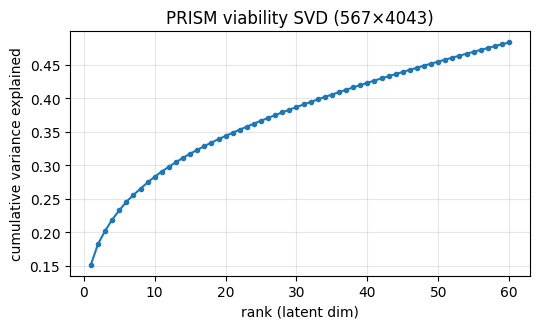

cumulative variance explained (mean-imputed):
  rank   4: 21.9%
  rank   8: 26.5%
  rank  16: 32.3%
  rank  32: 39.4%
  rank  64: 49.4%


In [13]:
# factorize the densest matrix (PRISM): mean-impute (per-drug) + center + SVD
M = mats["PRISM"]
filled = M.fillna(M.mean(axis=0)).fillna(M.stack().mean()).values
mu = filled.mean(0); Xc = filled - mu
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
cum = np.cumsum(S ** 2) / (S ** 2).sum()
plt.figure(figsize=(5.5, 3.4)); plt.plot(range(1, 61), cum[:60], marker=".")
plt.xlabel("rank (latent dim)"); plt.ylabel("cumulative variance explained")
plt.title(f"PRISM viability SVD ({M.shape[0]}×{M.shape[1]})"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("cumulative variance explained (mean-imputed):")
for k in [4, 8, 16, 32, 64]:
    print(f"  rank {k:>3}: {cum[k - 1]:.1%}")

In [14]:
# honest test: mask 10% of OBSERVED entries, fit on the rest, reconstruct held-out
from sklearn.metrics import r2_score
V = mats["PRISM"].values
obs = np.argwhere(~np.isnan(V))
rng = np.random.default_rng(0)
hold = obs[rng.choice(len(obs), int(0.1 * len(obs)), replace=False)]
Vtr = V.copy(); true_held = V[hold[:, 0], hold[:, 1]].copy()
Vtr[hold[:, 0], hold[:, 1]] = np.nan
cm = np.nanmean(Vtr, axis=0)                      # per-drug mean over remaining
filled = np.where(np.isnan(Vtr), cm, Vtr)
mu = filled.mean(0); U, S, Vt = np.linalg.svd(filled - mu, full_matrices=False)
print(f"baseline (per-drug mean) held-out R2 = {r2_score(true_held, cm[hold[:, 1]]):.3f}")
for k in [4, 8, 16, 32, 64]:
    rec = (U[:, :k] * S[:k]) @ Vt[:k] + mu
    print(f"  rank {k:>3}: held-out reconstruction R2 = {r2_score(true_held, rec[hold[:, 0], hold[:, 1]]):.3f}")

baseline (per-drug mean) held-out R2 = 0.603
  rank   4: held-out reconstruction R2 = 0.686
  rank   8: held-out reconstruction R2 = 0.697
  rank  16: held-out reconstruction R2 = 0.707
  rank  32: held-out reconstruction R2 = 0.710
  rank  64: held-out reconstruction R2 = 0.700


### 10b. Masked MF → the two embedding tables (and how to *select* a drug / cell line)

One decomposition of `V[cell_line × drug]` yields **both** tables at once:

`V[i, j]  ≈  μ + a_i + b_j + C[i] · D[j]`  — row *i* of `C` is the **cell-line** embedding, row *j* of
`D` is the **drug** embedding. "Selecting" an embedding is just indexing the right row; their dot
product (+ biases) reconstructs that pair's viability. Below is the *masked* MF (soft-impute: fit only
on observed entries) that cell 10's "Reading it" recommends — double-centered so the `k`-dim factors
capture the **interaction** `γ`, with the marginals `a_i`, `b_j` kept as a separate `bias` column.

In [ ]:
# masked / iterative MF (soft-impute): the REAL factors for the embeddings.
#   V[i,j] ~= mu + a_i + b_j + C[i] . D[j]   ->  ONE decomposition, BOTH tables.
import json, pathlib
RANK = 32
V = mats["PRISM"].values.astype(float)
obs = ~np.isnan(V)
# double-center on OBSERVED entries so the factors capture interaction gamma, not the marginals
mu = np.nanmean(V)
a = np.nanmean(V - mu, axis=1)                       # cell-line bias (marginal sensitivity)
R = V - mu - a[:, None]
b = np.nanmean(R, axis=0)                            # drug bias (marginal potency)
R = R - b[None, :]
# soft-impute: iterate truncated SVD, refilling ONLY the missing entries with the low-rank fit
X = np.where(obs, R, 0.0)
for _ in range(40):
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    X = np.where(obs, R, (U[:, :RANK] * S[:RANK]) @ Vt[:RANK])
U, S, Vt = np.linalg.svd(X, full_matrices=False)
C  = U[:, :RANK] * np.sqrt(S[:RANK])                 # (n_cl, k)  cell-line factors
Dm = Vt[:RANK].T * np.sqrt(S[:RANK])                 # (n_dr, k)  drug factors

cols = [f"f{i}" for i in range(RANK)]
cl_emb = pd.DataFrame(C,  index=mats["PRISM"].index,   columns=cols); cl_emb.insert(0, "bias", a)
dr_emb = pd.DataFrame(Dm, index=mats["PRISM"].columns, columns=cols); dr_emb.insert(0, "bias", b)
print("cell-line table:", cl_emb.shape, "  drug table:", dr_emb.shape)

out = pathlib.Path("viability_factors"); out.mkdir(exist_ok=True)
cl_emb.to_parquet(out / "cellline_embeddings.parquet")
dr_emb.to_parquet(out / "drug_embeddings.parquet")
json.dump({"dataset": "PRISM", "mu": float(mu), "rank": RANK,
           "n_celllines": int(V.shape[0]), "n_drugs": int(V.shape[1])},
          open(out / "meta.json", "w"), indent=2)
print("saved -> viability_factors/{cellline,drug}_embeddings.parquet")

# --- SELECT the embeddings for one (cell_line, drug) and reconstruct its viability ---
cl_name, dr_name = mats["PRISM"].index[0], mats["PRISM"].columns[0]
c_vec = cl_emb.loc[cl_name, cols].values
d_vec = dr_emb.loc[dr_name, cols].values
pred  = mu + cl_emb.loc[cl_name, "bias"] + dr_emb.loc[dr_name, "bias"] + c_vec @ d_vec
print(f"\nselect cell_line={cl_name!r}: {RANK}-d vector {np.round(c_vec[:4], 3)} ...")
print(f"select drug   smiles[:24]={dr_name[:24]!r}: {RANK}-d vector {np.round(d_vec[:4], 3)} ...")
print(f"reconstructed viability = {pred:.3f}   (true {V[0, 0]:.3f})")


cell-line table: (567, 33)   drug table: (4043, 33)


saved -> viability_factors/{cellline,drug}_embeddings.parquet

select cell_line='22RV1': 32-d vector [-0.099  0.003 -0.024  0.115] ...
select drug   smiles[:24]=', CCCCCCCCCCCCCCCC(=O)OC': 32-d vector [0.02  0.006 0.019 0.014] ...
reconstructed viability = 0.647   (true 0.547)


**Reading it:**
- **Per-dataset matrices are dense** (PRISM ~97%, CTRP/GDSC ~80–85%) → factorize each dataset on its
  own and missingness is mild. The "massive nulls" appear only when **pooling datasets** onto one drug
  axis (drugs barely overlap → block-sparse), so don't pool raw — factorize per dataset, or align on a
  shared SMILES/InChIKey axis first.
- **Filtering** (drop cell lines / drugs with <N measurements) trims the long tail and lifts density.
- **Latent dim:** the SVD curve + the *held-out* reconstruction R² (vs the per-drug-mean baseline) show
  how many factors are *real* (beat the marginal). Use the rank where held-out R² plateaus as the
  drug / cell-line embedding size.
- **Imputation:** mean-impute is the quick baseline (and biases the SVD toward the fill value); for the
  final embeddings use a **masked / iterative MF** (fit only on observed entries). Then anchor the drug
  latent to SMILES and the cell-line latent to expression for test-time generalization.

## Summary

- **Per-dataset:** PRISM dominates on drug breadth (near-complete grid, most compounds); GDSC/CTRP
  have more cell lines but fewer drugs.
- **Viability:** different scales per assay (PRISM ≈ 0.64, GDSC ≈ 0.51, CTRP ≈ 0.92) — use rank, not raw.
- **Completeness:** PRISM is a dense grid; GDSC/CTRP are denser per-cell-line but on a smaller drug set.
- **Quality:** SMILES carries a comma-repeat quirk for some PRISM rows → canonicalize (InChIKey) before
  treating SMILES as the drug key.
- **Overlap:** cell lines overlap heavily (shared axis); drugs barely (complementary libraries) → combining
  adds cell-line breadth + ~700 new compounds, not redundancy.